In [51]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [52]:
df = yf.download("^NSEI", start="2019-06-06",end= '2026-01-01',auto_adjust=False,multi_level_index=False)
df.drop(columns=['Close','High','Low','Open','Volume'], inplace=True)

df['returns'] = np.log(df['Adj Close']/df['Adj Close'].shift(1))
df['lag1'] = df['returns'].shift(1)

df.dropna(inplace=True)
df = df[['lag1','returns']]
x = df[['lag1']]
y = df['returns']


[*********************100%***********************]  1 of 1 completed


In [53]:
from sklearn.linear_model import LinearRegression
window = 75
coef = []
forecast = []
date = []

for i in range(window,len(df)):

    x_train = x.iloc[i-window:i]
    y_train = y.iloc[i-window:i]

    x_test = x.iloc[i:i+1]

    model = LinearRegression().fit(x_train, y_train)
    pred = model.predict(x_test)

    forecast.append(pred[0])
    coef.append(model.coef_[0])
    date.append(x_test.index[0])

results = pd.DataFrame({"prediction":forecast,"coef":coef},index=date)
results['returns'] = df.loc[results.index,'returns']
results['residual'] = results['returns'] - results['prediction']
results = results[['returns','prediction','residual','coef']]


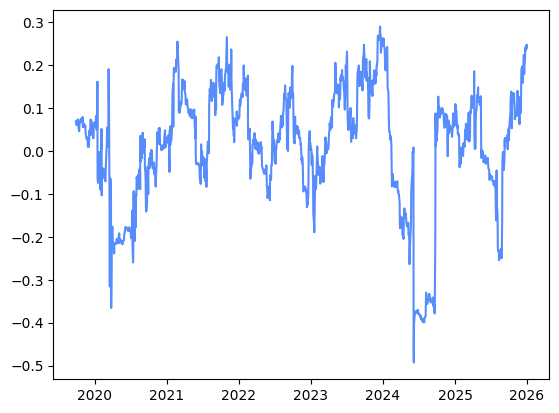

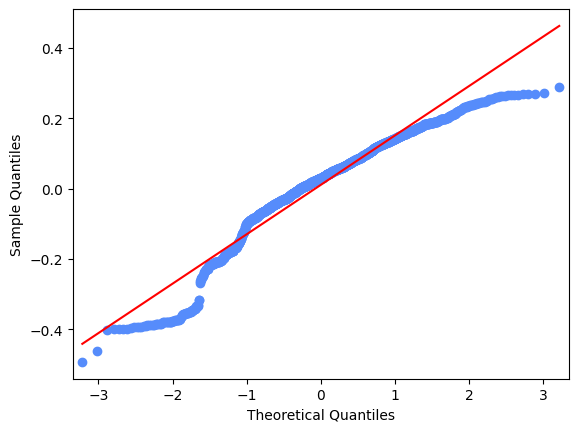

In [54]:
plt.plot(results['coef'],label='coef')
plt.show()

import statsmodels.api as sm
sm.qqplot(results['coef'],line='s',label='coef')
plt.show()


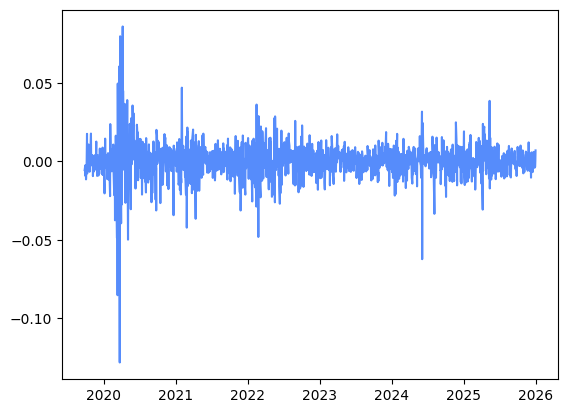

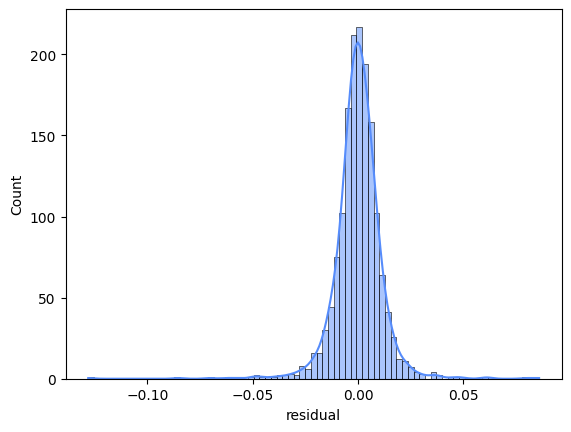

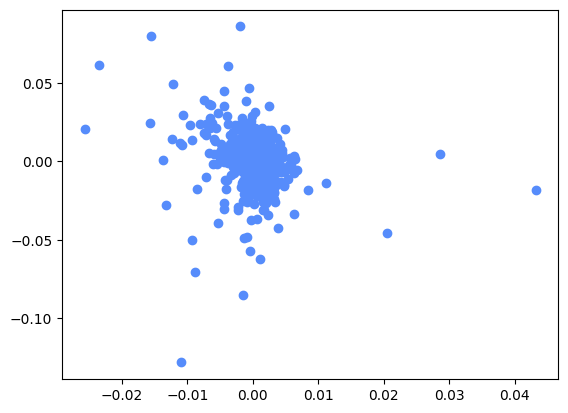

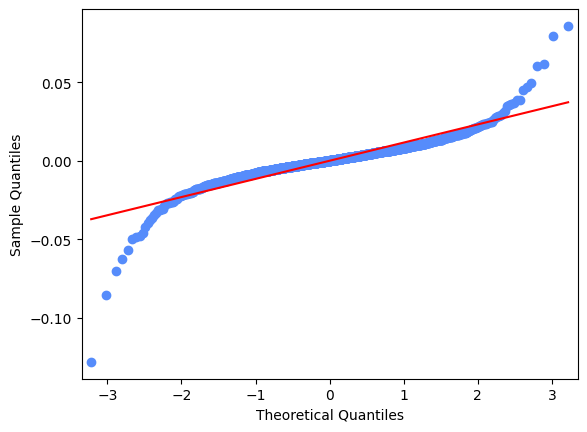

In [55]:
plt.plot(results['residual'],label='residual')
plt.show()

sns.histplot(results['residual'],kde=True)
plt.show()

plt.scatter(results['prediction'],results['residual'],label='residual')
plt.show()

sm.qqplot(results['residual'],line='s',label='residual')
plt.show()